In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from datetime import datetime
import os

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

meeting_file = os.path.join(
    project_folder,
    "data",
    "meetings.xlsx"
)

In [3]:
meeting_df = pd.read_excel(meeting_file)

meeting_df.head()

,Meeting_ID,Meeting_Date,Meeting_Time,Client_Name,Department,Agenda,Duration_Minutes,Status,Location
0,MT001,2026-07-06 20:21:07.233,9:30,"Dhar, Mahajan and Kara",Finance,Budget Meeting,91,Completed,Google Meet
1,MT002,2026-07-08 20:21:07.233,12:00,Johal-Ramaswamy,Marketing,Weekly Sync,47,Completed,Zoom
2,MT003,2026-07-08 20:21:07.233,9:30,Datta-Nigam,Sales,Sales Pitch,118,Cancelled,Google Meet
3,MT004,2026-06-22 20:21:07.233,14:30,Nazareth-Zacharia,Operations,Vendor Discussion,84,Completed,Zoom
4,MT005,2026-06-05 20:21:07.233,11:00,Soni-Goel,HR,Weekly Sync,94,Scheduled,Conference Room A


In [4]:
meeting_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Meeting_ID        100 non-null    object        
 1   Meeting_Date      100 non-null    datetime64[ns]
 2   Meeting_Time      100 non-null    object        
 3   Client_Name       100 non-null    object        
 4   Department        100 non-null    object        
 5   Agenda            100 non-null    object        
 6   Duration_Minutes  100 non-null    int64         
 7   Status            100 non-null    object        
 8   Location          100 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 7.2+ KB


In [5]:
meeting_df.describe(include="all")

,Meeting_ID,Meeting_Date,Meeting_Time,Client_Name,Department,Agenda,Duration_Minutes,Status,Location
count,100,100,100,100,100,100,100.00000,100,100
unique,100,NaN,20,100,6,6,NaN,3,4
top,MT001,NaN,17:00,"Dhar, Mahajan and Kara",Finance,Vendor Discussion,NaN,Completed,Google Meet
freq,1,NaN,9,1,21,21,NaN,38,29
mean,NaN,2026-06-26 02:35:31.234919936,NaN,NaN,NaN,NaN,75.78000,NaN,NaN
min,NaN,2026-05-29 20:21:07.233000,NaN,NaN,NaN,NaN,31.00000,NaN,NaN
25%,NaN,2026-06-11 20:21:07.235749888,NaN,NaN,NaN,NaN,54.75000,NaN,NaN
50%,NaN,2026-06-25 08:21:07.235500032,NaN,NaN,NaN,NaN,76.50000,NaN,NaN
75%,NaN,2026-07-07 08:21:07.235249920,NaN,NaN,NaN,NaN,98.50000,NaN,NaN
max,NaN,2026-07-28 20:21:07.235000,NaN,NaN,NaN,NaN,119.00000,NaN,NaN


In [6]:
meeting_df.isnull().sum()

Meeting_ID          0
Meeting_Date        0
Meeting_Time        0
Client_Name         0
Department          0
Agenda              0
Duration_Minutes    0
Status              0
Location            0
dtype: int64

In [7]:
meeting_df["Meeting_Date"] = pd.to_datetime(
    meeting_df["Meeting_Date"]
)

In [8]:
meeting_df["Year"] = meeting_df["Meeting_Date"].dt.year
meeting_df["Month"] = meeting_df["Meeting_Date"].dt.month_name()
meeting_df["Day"] = meeting_df["Meeting_Date"].dt.day_name()

meeting_df.head()

,Meeting_ID,Meeting_Date,Meeting_Time,Client_Name,Department,Agenda,Duration_Minutes,Status,Location,Year,Month,Day
0,MT001,2026-07-06 20:21:07.233,9:30,"Dhar, Mahajan and Kara",Finance,Budget Meeting,91,Completed,Google Meet,2026,July,Monday
1,MT002,2026-07-08 20:21:07.233,12:00,Johal-Ramaswamy,Marketing,Weekly Sync,47,Completed,Zoom,2026,July,Wednesday
2,MT003,2026-07-08 20:21:07.233,9:30,Datta-Nigam,Sales,Sales Pitch,118,Cancelled,Google Meet,2026,July,Wednesday
3,MT004,2026-06-22 20:21:07.233,14:30,Nazareth-Zacharia,Operations,Vendor Discussion,84,Completed,Zoom,2026,June,Monday
4,MT005,2026-06-05 20:21:07.233,11:00,Soni-Goel,HR,Weekly Sync,94,Scheduled,Conference Room A,2026,June,Friday


In [9]:
total_meetings = len(meeting_df)

completed = len(
    meeting_df[
        meeting_df["Status"]=="Completed"
    ]
)

scheduled = len(
    meeting_df[
        meeting_df["Status"]=="Scheduled"
    ]
)

cancelled = len(
    meeting_df[
        meeting_df["Status"]=="Cancelled"
    ]
)

total_hours = round(
    meeting_df["Duration_Minutes"].sum()/60,
    2
)

average_duration = round(
    meeting_df["Duration_Minutes"].mean(),
    2
)

In [10]:
print("="*50)

print("MEETING DASHBOARD KPI")

print("="*50)

print(f"Total Meetings : {total_meetings}")

print(f"Completed      : {completed}")

print(f"Scheduled      : {scheduled}")

print(f"Cancelled      : {cancelled}")

print(f"Meeting Hours  : {total_hours}")

print(f"Average Duration : {average_duration} minutes")

MEETING DASHBOARD KPI
Total Meetings : 100
Completed      : 38
Scheduled      : 29
Cancelled      : 33
Meeting Hours  : 126.3
Average Duration : 75.78 minutes


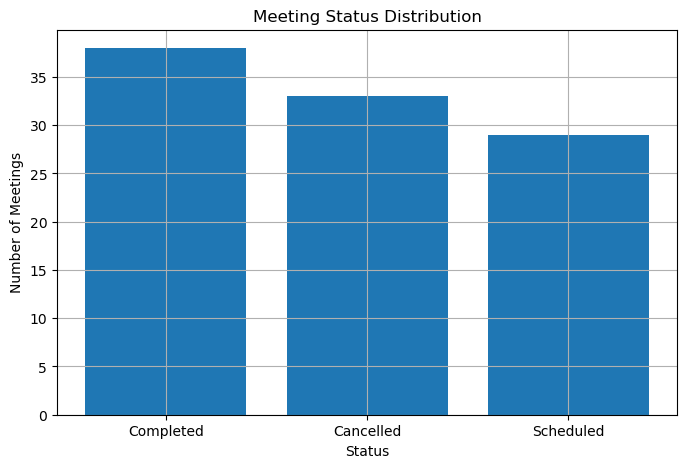

In [11]:
status_count = meeting_df["Status"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_count.index, status_count.values)

plt.title("Meeting Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Meetings")

plt.grid(True)

plt.show()

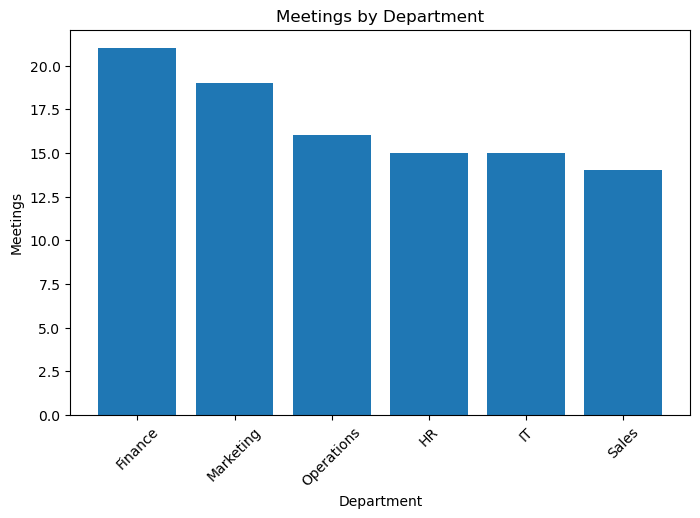

In [12]:
department_count = meeting_df["Department"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    department_count.index,
    department_count.values
)

plt.title("Meetings by Department")
plt.xlabel("Department")
plt.ylabel("Meetings")

plt.xticks(rotation=45)

plt.show()

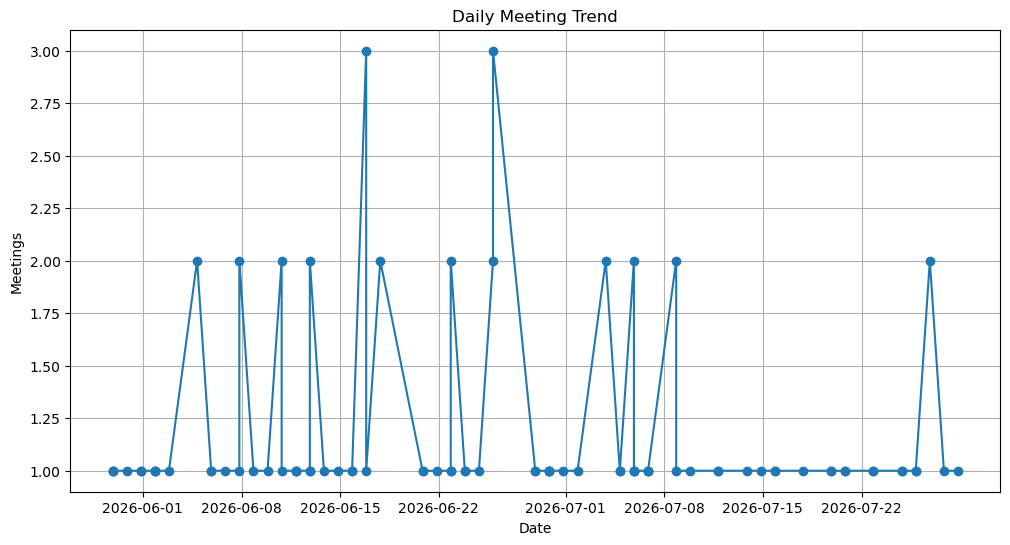

In [13]:
daily = meeting_df.groupby(
    "Meeting_Date"
).size()

plt.figure(figsize=(12,6))

plt.plot(
    daily.index,
    daily.values,
    marker='o'
)

plt.title("Daily Meeting Trend")
plt.xlabel("Date")
plt.ylabel("Meetings")

plt.grid(True)

plt.show()

In [14]:
top_clients = (
    meeting_df["Client_Name"]
    .value_counts()
    .head(10)
)

print(top_clients)

Client_Name
Dhar, Mahajan and Kara                 1
Chander, Krishnamurthy and Choudhry    1
Raghavan-Raj                           1
Sharaf Group                           1
Shenoy, Naik and Balan                 1
Date-Saha                              1
Shanker-Dash                           1
Prabhakar Group                        1
Goel-Dutt                              1
Deep-Prakash                           1
Name: count, dtype: int64


In [15]:
summary = pd.DataFrame({

    "Metric":[

        "Total Meetings",
        "Completed",
        "Scheduled",
        "Cancelled",
        "Meeting Hours",
        "Average Duration"

    ],

    "Value":[

        total_meetings,
        completed,
        scheduled,
        cancelled,
        total_hours,
        average_duration

    ]

})

summary.to_excel(
    os.path.join(
        project_folder,
        "reports",
        "Meeting_Summary.xlsx"
    ),
    index=False
)

print("Meeting Summary Saved Successfully")

Meeting Summary Saved Successfully
